# IA column: 2024 edition vs. 2025 edition

**Why this notebook exists.** When we swapped the model onto the latest LBNL *Queued Up* workbook (data through 2025), the `ia_executed` feature began *perfectly* separating outcomes: in the training pool every completed (operational) project had an executed IA, so a project **without** an IA is, historically, a guaranteed withdrawal. That collapsed the model onto a single rule and pinned ~70% of active projects at 0.999.

This notebook compares the **interconnection-agreement status column** between the two editions to show *what changed in the data* and decide how to treat the feature.

- **2024 edition** (`...thru2024_v2.xlsx`): IA column is `IA_status_clean`.
- **2025 edition** (`...thru2025.xlsx`): IA column renamed to `IA_phase_clean`.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option('display.max_columns', 30)

# Both editions live in the project's data/ directory (paths are relative to
# this notebook under notebooks/).
DATA = '../data'
F2024 = f'{DATA}/LBNL_Ix_Queue_Data_File_thru2024_v2.xlsx'
F2025 = f'{DATA}/LBNL_Ix_Queue_Data_File_thru2025.xlsx'
SHEET = '03. Complete Queue Data'

# Same definition the model uses (model/train.py).
IA_EXECUTED_STATUSES = {'IA Executed', 'Construction', 'Operational', 'Combined'}
MODELED = ['active', 'withdrawn', 'operational', 'suspended']

def load(path, ia_col):
    df = pd.read_excel(path, sheet_name=SHEET, header=1, na_values=['NA'])
    df = df[df['q_status'].isin(MODELED)].copy()
    # Normalize the IA column name so both editions are comparable.
    df['ia_clean'] = df[ia_col]
    # Reproduce the model's cumulative 'reached IA execution' flag.
    df['ia_executed'] = (
        df['ia_clean'].isin(IA_EXECUTED_STATUSES) | df['ia_date'].notna()
    ).astype(int)
    df['resolved'] = df['q_status'].isin(['withdrawn', 'operational'])
    df['withdrawn'] = (df['q_status'] == 'withdrawn').astype(int)
    return df

df24 = load(F2024, 'IA_status_clean')
df25 = load(F2025, 'IA_phase_clean')
print('2024 rows:', len(df24), '| 2025 rows:', len(df25))


2024 rows: 36437 | 2025 rows: 38191


## 1. IA category distribution
How the IA-status categories themselves shifted. Note the 2024 column carries an explicit `Operational` value; the 2025 `IA_phase_clean` does not.

,2024 %,2025 %
ia_clean,,
Cluster Study,5.2,5.4
Combined,0.0,0.0
Construction,0.1,0.6
Facility Study,10.0,9.7
Feasibility Study,6.7,11.9
IA Executed,16.8,30.9
IA Pending,0.4,1.9
In Progress (unknown study),16.4,8.0
Not Started,0.9,1.0


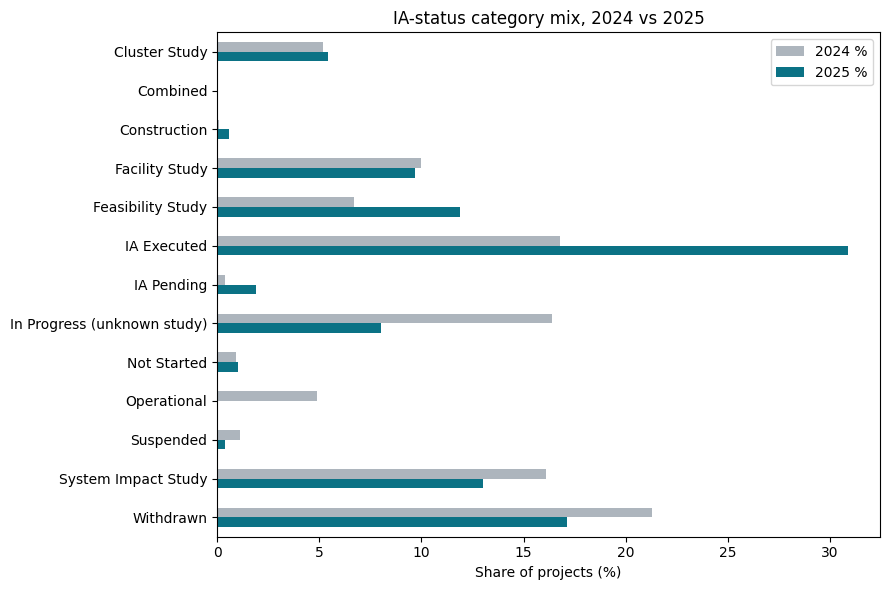

In [2]:
order = sorted(set(df24['ia_clean'].dropna().unique()) |
               set(df25['ia_clean'].dropna().unique()))
def share(df):
    return (df['ia_clean'].value_counts(normalize=True)
            .reindex(order).fillna(0) * 100)
tbl = pd.DataFrame({'2024 %': share(df24), '2025 %': share(df25)}).round(1)
display(tbl)

ax = tbl.plot.barh(figsize=(9, 6), color=['#adb5bd', '#0b7285'])
ax.set_xlabel('Share of projects (%)'); ax.set_ylabel('')
ax.set_title('IA-status category mix, 2024 vs 2025'); ax.invert_yaxis()
plt.tight_layout(); plt.show()


## 2. IA category vs. final outcome
For each edition, the outcome mix within each IA category (row-normalized). This shows which IA categories lead to completion vs. withdrawal.

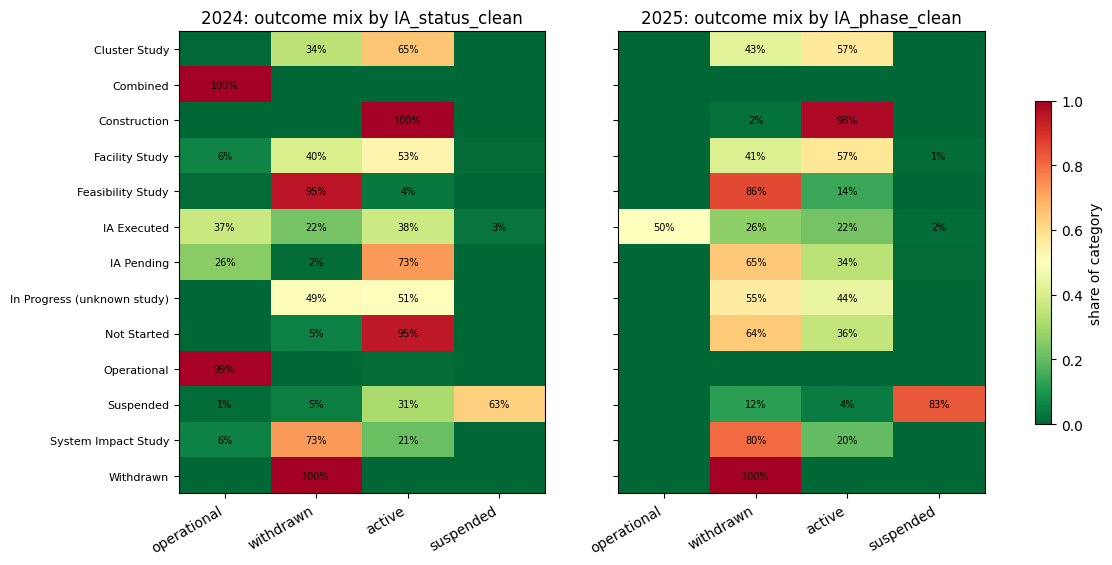

In [3]:
def outcome_heat(df, title, ax):
    ct = pd.crosstab(df['ia_clean'], df['q_status'])
    for c in ['operational', 'withdrawn', 'active', 'suspended']:
        if c not in ct: ct[c] = 0
    ct = ct[['operational', 'withdrawn', 'active', 'suspended']]
    frac = ct.div(ct.sum(axis=1), axis=0).reindex(order).fillna(0)
    im = ax.imshow(frac.values, aspect='auto', cmap='RdYlGn_r', vmin=0, vmax=1)
    ax.set_xticks(range(4)); ax.set_xticklabels(frac.columns, rotation=30, ha='right')
    ax.set_yticks(range(len(frac))); ax.set_yticklabels(frac.index, fontsize=8)
    ax.set_title(title)
    for i in range(frac.shape[0]):
        for j in range(frac.shape[1]):
            v = frac.values[i, j]
            if v > 0.01:
                ax.text(j, i, f'{v:.0%}', ha='center', va='center', fontsize=7)
    return im

fig, axes = plt.subplots(1, 2, figsize=(13, 6), sharey=True)
outcome_heat(df24, '2024: outcome mix by IA_status_clean', axes[0])
im = outcome_heat(df25, '2025: outcome mix by IA_phase_clean', axes[1])
fig.colorbar(im, ax=axes, shrink=0.7, label='share of category')
plt.show()


## 3. The crux: do completed projects ever lack an IA?
The model trains on **resolved** projects. The feature breaks if *completed* projects always have an IA, because then 'no IA' becomes a perfect predictor of withdrawal. Here is the IA-status mix of **operational** projects in each edition, and the share of completed projects flagged `ia_executed == 0`.

In [4]:
op24 = df24[df24['q_status'] == 'operational']
op25 = df25[df25['q_status'] == 'operational']
comp = pd.DataFrame({
    '2024 %': op24['ia_clean'].value_counts(normalize=True).reindex(order).fillna(0) * 100,
    '2025 %': op25['ia_clean'].value_counts(normalize=True).reindex(order).fillna(0) * 100,
}).round(1)
display(comp[(comp.T != 0).any()])

print('Share of OPERATIONAL (completed) projects with ia_executed == 0:')
print(f'  2024: {(op24["ia_executed"] == 0).mean():.1%}')
print(f'  2025: {(op25["ia_executed"] == 0).mean():.1%}   <- drives the perfect separation')


,2024 %,2025 %
ia_clean,,
Cluster Study,0.2,0.0
Facility Study,4.7,0.0
Feasibility Study,0.4,0.0
IA Executed,48.2,100.0
IA Pending,0.9,0.0
In Progress (unknown study),0.5,0.0
Operational,37.8,0.0
Suspended,0.1,0.0
System Impact Study,7.3,0.0


Share of OPERATIONAL (completed) projects with ia_executed == 0:
  2024: 22.3%
  2025: 0.0%   <- drives the perfect separation


## 4. Resulting separation of the `ia_executed` feature
Withdrawal rate among **resolved** projects, split by the `ia_executed` flag. A bar reaching 100% for `no IA` means perfect separation — exactly the degeneracy that pins active no-IA projects at ~0.999.

,2024,2025
no IA (ia_executed=0),95.2,100.0
has IA (ia_executed=1),25.5,37.7


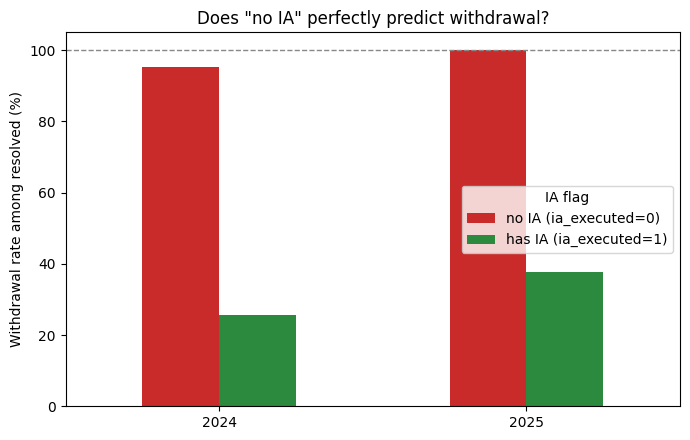

2024: of 20731 resolved no-IA projects, 987 actually completed (4.8%) -> no perfect separation
2025: of 21317 resolved no-IA projects, 0 actually completed (0.0%) -> perfect separation


In [5]:
def sep(df):
    r = df[df['resolved']]
    return pd.Series({
        'no IA (ia_executed=0)': r.loc[r['ia_executed'] == 0, 'withdrawn'].mean(),
        'has IA (ia_executed=1)': r.loc[r['ia_executed'] == 1, 'withdrawn'].mean(),
    }) * 100
sep_tbl = pd.DataFrame({'2024': sep(df24), '2025': sep(df25)}).round(1)
display(sep_tbl)

ax = sep_tbl.T.plot.bar(figsize=(7, 4.5), color=['#c92a2a', '#2b8a3e'], rot=0)
ax.set_ylabel('Withdrawal rate among resolved (%)'); ax.set_ylim(0, 105)
ax.axhline(100, ls='--', lw=1, color='#888')
ax.set_title('Does "no IA" perfectly predict withdrawal?')
ax.legend(title='IA flag'); plt.tight_layout(); plt.show()

n24 = (df24['resolved'] & (df24['ia_executed'] == 0)).sum()
comp24 = ((df24['q_status'] == 'operational') & (df24['ia_executed'] == 0)).sum()
print(f'2024: of {n24} resolved no-IA projects, {comp24} actually completed '
      f'({comp24/n24:.1%}) -> no perfect separation')
n25 = (df25['resolved'] & (df25['ia_executed'] == 0)).sum()
comp25 = ((df25['q_status'] == 'operational') & (df25['ia_executed'] == 0)).sum()
print(f'2025: of {n25} resolved no-IA projects, {comp25} actually completed '
      f'({comp25/n25:.1%}) -> perfect separation')


## Takeaway
If 2024's *completed-but-no-IA* projects (section 3) were a **data-coding artifact** that the 2025 edition cleaned up, then 'no IA ⇒ withdrawal' is a genuine structural fact and keeping the feature is defensible. If instead those 2024 cases were **real completions that genuinely lacked a recorded IA**, the 2025 perfect separation is mostly tighter bookkeeping and the feature now overstates certainty for early-stage active projects. Sections 2–3 are where to look: inspect *which* 2024 categories the completed-no-IA projects fall into.